In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df=pd.read_excel("Crop Recommendation Dataset.xlsx")

In [4]:
df.describe()

,Temperature,Humidity,pH,Rainfall
count,7000.000000,7000.000000,7000.000000,7000.000000
mean,23.493807,71.318934,6.454138,751.476229
std,6.755644,22.289074,0.667650,825.472175
min,6.105382,6.029440,3.504752,20.211267
25%,18.948438,58.055782,6.049754,123.595859
50%,23.344269,77.238068,6.406537,644.904867
75%,27.686253,90.259315,6.859321,1051.049795
max,46.791488,99.981876,9.935091,5989.995521


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  7000 non-null   float64
 1   Humidity     7000 non-null   float64
 2   pH           7000 non-null   float64
 3   Rainfall     7000 non-null   float64
 4   Label        7000 non-null   object 
dtypes: float64(4), object(1)
memory usage: 273.6+ KB


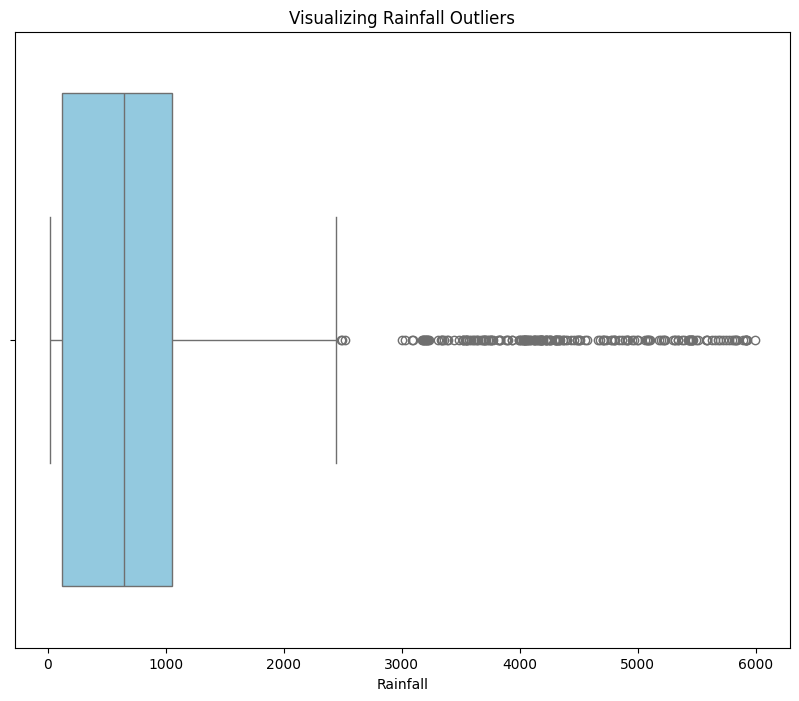

In [8]:
plt.figure(figsize=(10,8))
sns.boxplot(x=df['Rainfall'],color="skyblue")
plt.title("Visualizing Rainfall Outliers")
plt.show()

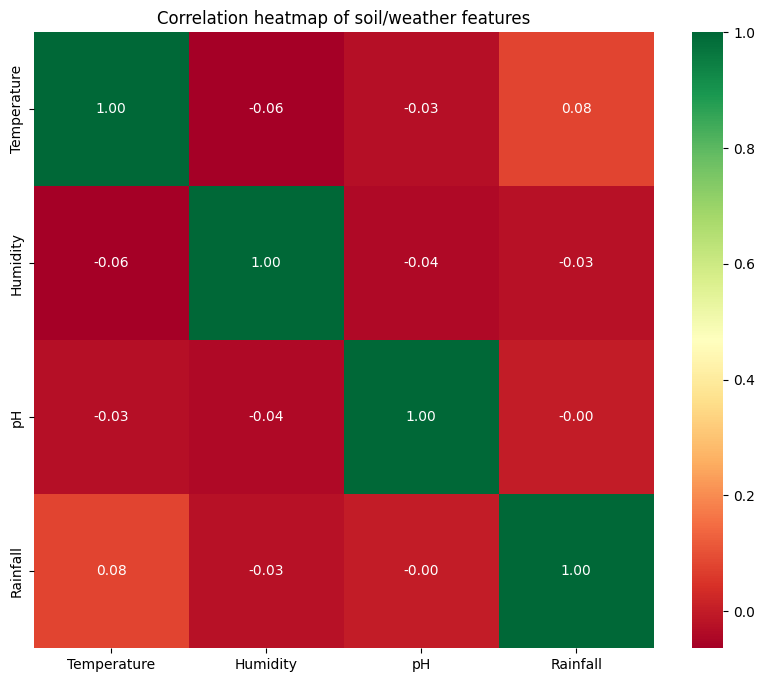

In [16]:
corr_matrix=X.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",cmap="RdYlGn")
plt.title("Correlation heatmap of soil/weather features")
plt.show()

In [13]:
X=df.drop("Label",axis=1)
y=df["Label"]

In [14]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
scaler=MinMaxScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [16]:
model=RandomForestClassifier(n_estimators=100,random_state=42)

model.fit(X_train_scaled,y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
pred=model.predict(X_test_scaled)

In [18]:
print(f"Accuracy : {accuracy_score(pred,y_test)}")

Accuracy : 0.9657142857142857


In [19]:

print("--- Detailed Performance Report ---")
print(classification_report(y_test, pred))

--- Detailed Performance Report ---
                  precision    recall  f1-score   support

        Aleovera       1.00      1.00      1.00        12
           Apple       0.90      0.95      0.93        20
        Arecanut       1.00      0.93      0.97        15
     Ashwagandha       1.00      1.00      1.00        25
           Bajra       1.00      1.00      1.00        21
          Banana       1.00      1.00      1.00        22
        Beetroot       1.00      1.00      1.00        29
       Blackgram       0.88      1.00      0.94        15
         Brinjal       0.95      1.00      0.97        19
        Broccoli       1.00      1.00      1.00        18
Button Mushrooms       0.74      0.67      0.70        21
         Cabbage       0.94      1.00      0.97        15
        Capsicum       0.86      0.95      0.90        19
          Carrot       1.00      1.00      1.00        20
      Cashewnuts       1.00      0.87      0.93        23
     Cauliflower       1.00      1.

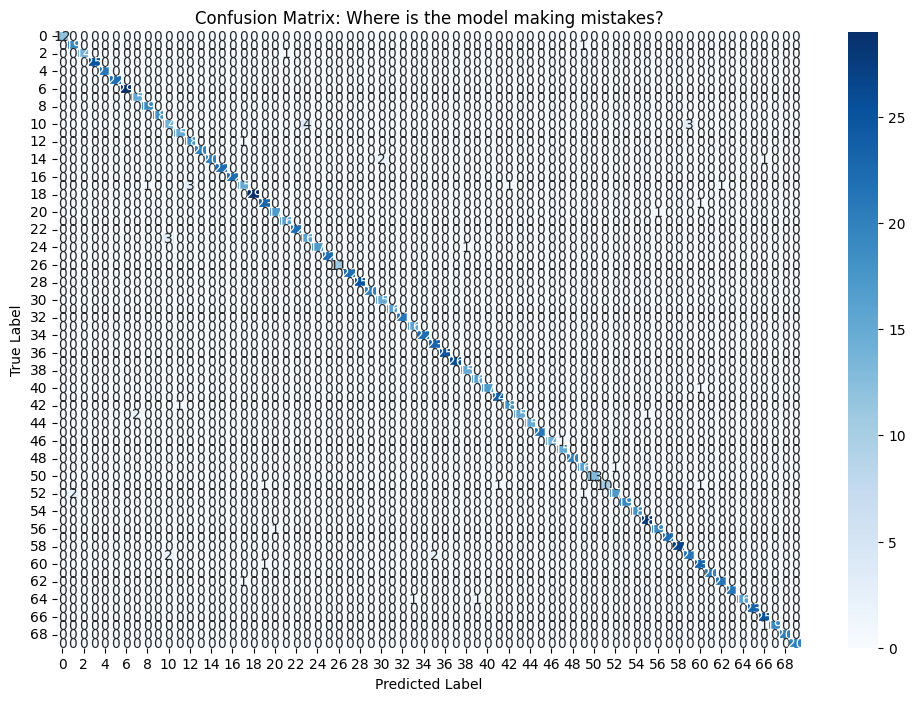

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, cmap='Blues')
plt.title("Confusion Matrix: Where is the model making mistakes?")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [22]:
import joblib
joblib.dump(model, 'crop_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
